# Importing Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")  # Clean white background

print(" Libraries loaded successfully")

 Libraries loaded successfully


# Section 1: Data Loading

In [33]:
df_real = pd.read_csv('C:/Users/Dell/Desktop/github projects/Healthcare Capstone Project(3 in 1)/AI Healthcare excel project/processed/diabetic_data_for_mostlyai.csv')
df_synthetic = pd.read_csv('C:/Users/Dell/Desktop/github projects/Healthcare Capstone Project(3 in 1)/AI Healthcare excel project/synthetic/diabetic_data_synthetic.csv')

df_real['data_source'] = 'Real'
df_synthetic['data_source'] = 'Synthetic'

df_combined = pd.concat([df_real, df_synthetic], ignore_index=True) # combined both datasets and resets row number

print(f"Real Data Shape:      {df_real.shape}")      
print(f"Synthetic Data Shape: {df_synthetic.shape}") 
print(f"Combined Shape:       {df_combined.shape}")   

Real Data Shape:      (98052, 32)
Synthetic Data Shape: (98052, 32)
Combined Shape:       (196104, 32)


# Section 2 : Readmission Distribution

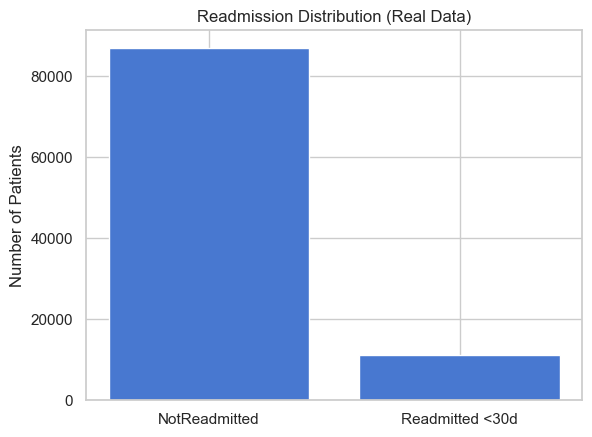

<Figure size 1000x600 with 0 Axes>

In [34]:
fig,ax = plt.subplots()
plt.figure(figsize = (10,6))

count = df_real["readmitted_binary"].value_counts().sort_index()
labels = ["NotReadmitted","Readmitted <30d"]
ax.bar(labels, count.values)
ax.set_title("Readmission Distribution (Real Data)")
ax.set_ylabel("Number of Patients")

plt.tight_layout()
fig.savefig("C:/Users/Dell/Desktop/github projects/Healthcare Capstone Project(3 in 1)/AI Healthcare excel project/visuals/readmission_distribution.png", dpi=150)
plt.show()

# Section 3: Age vs Readmission Rate

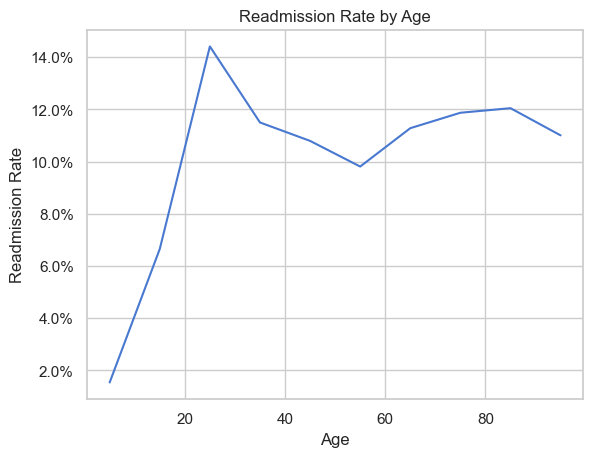

<Figure size 1000x600 with 0 Axes>

In [35]:
from matplotlib.ticker import PercentFormatter
fig,ax = plt.subplots()
plt.figure(figsize = (10,6))

age_read = df_real.groupby('age')['readmitted_binary'].mean().sort_index()
ax.plot(age_read.index, age_read.values)
ax.set_title("Readmission Rate by Age")
ax.set_xlabel("Age")
ax.set_ylabel("Readmission Rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
fig.savefig("C:/Users/Dell/Desktop/github projects/Healthcare Capstone Project(3 in 1)/AI Healthcare excel project/visuals/age_vs_readmission.png", dpi=150)
plt.show()

# Section 4: Real vs Synthetic Data Distribution

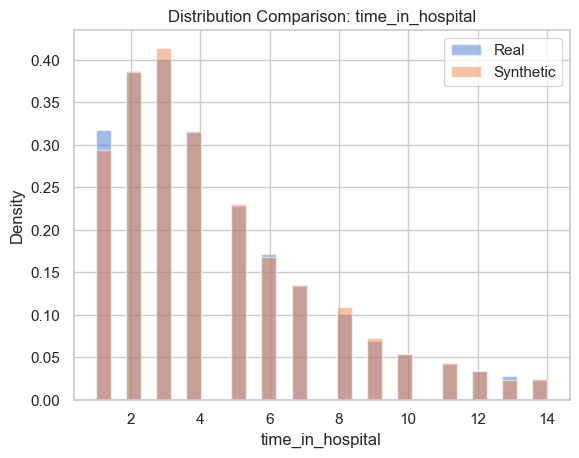

<Figure size 800x600 with 0 Axes>

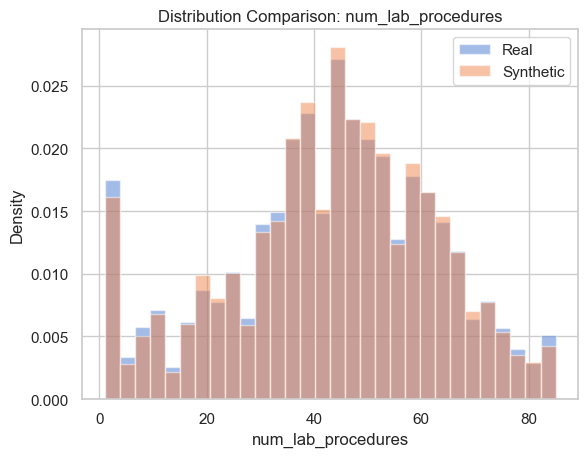

<Figure size 800x600 with 0 Axes>

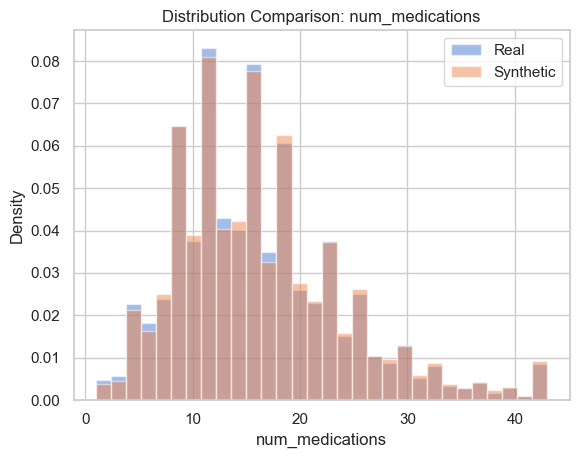

<Figure size 800x600 with 0 Axes>

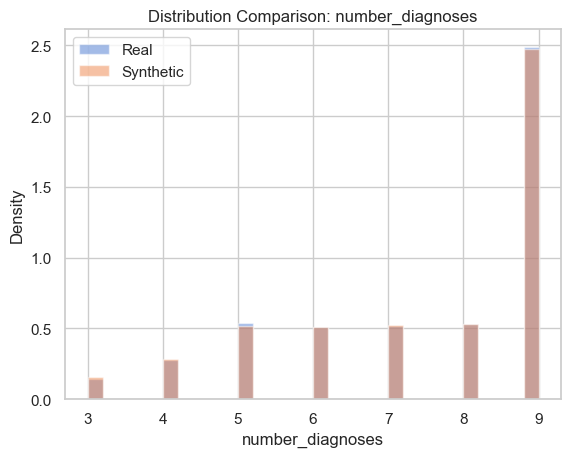

<Figure size 800x600 with 0 Axes>

In [36]:
numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_medications", "number_diagnoses"]

for col in numeric_cols:
    
    fig, ax = plt.subplots()
    plt.figure(figsize = (8,6))
    ax.hist(
        df_real[col],
        bins=30,
        density=True,
        alpha=0.5,
        label="Real"
    )
    ax.hist(
        df_synthetic[col],
        bins=30,
        density=True,
        alpha=0.5,
        label="Synthetic"
    )
    ax.set_title(f"Distribution Comparison: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    fig.savefig(f"C:/Users/Dell/Desktop/github projects/Healthcare Capstone Project(3 in 1)/AI Healthcare excel project/visuals/{col}_comparison.png", dpi=150)
    plt.show()

# Section 5: Correlation Heatmap

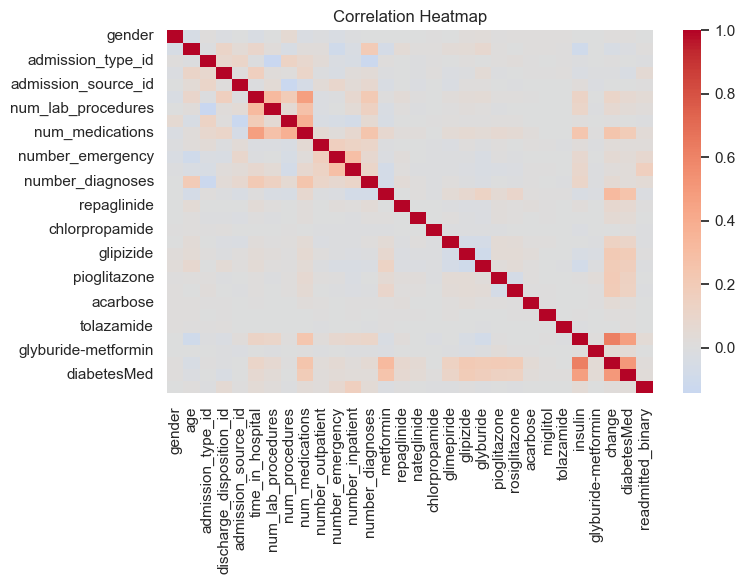

In [37]:
numeric_df = df_real.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    ax=ax
)

ax.set_title("Correlation Heatmap")

plt.tight_layout()
fig.savefig("C:/Users/Dell/Desktop/github projects/Healthcare Capstone Project(3 in 1)/AI Healthcare excel project/visuals/correlation_heatmap.png", dpi=150)
plt.show()


# Section 6 : Insulin Usage vs Readmission Rate

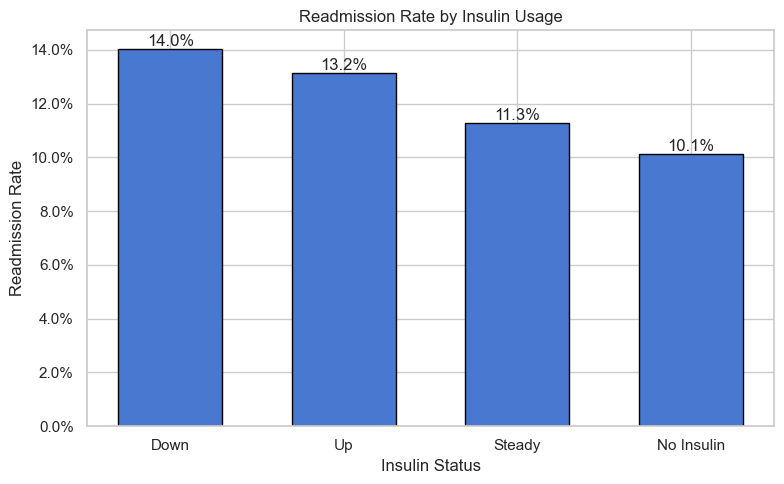

Key Insight: Patients with reduced insulin show the highest readmission rate.


In [38]:
insulin_labels = { 0: 'No Insulin', 1: 'Steady', 2: 'Up', 3: 'Down'}
insulin_readmit = (df_real.groupby('insulin')['readmitted_binary'].mean().reset_index())
insulin_readmit['insulin'] = insulin_readmit['insulin'].map(insulin_labels)
insulin_readmit = insulin_readmit.sort_values(by='readmitted_binary', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    insulin_readmit['insulin'],
    insulin_readmit['readmitted_binary'],
    edgecolor='black',
    width=0.6
)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1%}',
        ha='center',
        va='bottom'
    )

ax.set_title('Readmission Rate by Insulin Usage')
ax.set_xlabel('Insulin Status')
ax.set_ylabel('Readmission Rate')
ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
fig.savefig('C:/Users/Dell/Desktop/github projects/Healthcare Capstone Project(3 in 1)/AI Healthcare excel project/visuals/insulin_vs_readmission.png', dpi=150)
plt.show()

print("Key Insight: Patients with reduced insulin show the highest readmission rate.")

# Section 7: Prior Inpatient vs Readmission

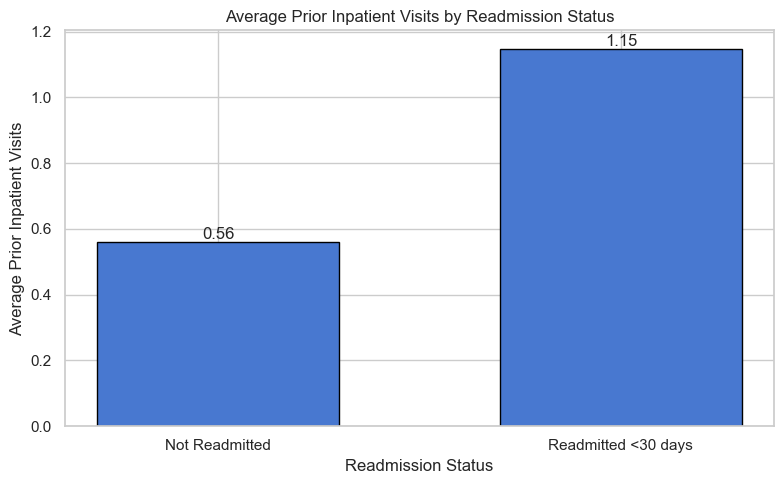

Key Insight: Readmitted patients had significantly more prior inpatient visits.


In [39]:
inpatient_avg = (df_real.groupby('readmitted_binary')['number_inpatient'] .mean() .reset_index())
labels= {0: "Not Readmitted", 1: "Readmitted <30 days"}
inpatient_avg['readmitted_binary'] = inpatient_avg['readmitted_binary'].map(labels)
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    inpatient_avg['readmitted_binary'],
    inpatient_avg['number_inpatient'],
    edgecolor='black',
    width=0.6
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )
ax.set_title('Average Prior Inpatient Visits by Readmission Status')
ax.set_xlabel('Readmission Status')
ax.set_ylabel('Average Prior Inpatient Visits')

plt.tight_layout()
fig.savefig('C:/Users/Dell/Desktop/github projects/Healthcare Capstone Project(3 in 1)/AI Healthcare excel project/visuals/inpatient_visits_vs_readmission.png', dpi=150)
plt.show()

print("Key Insight: Readmitted patients had significantly more prior inpatient visits.")